In [1]:
import os
import json
import time
import copy
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.amp import autocast, GradScaler
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    matthews_corrcoef,
    balanced_accuracy_score,
    confusion_matrix,
    classification_report
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [2]:
SEED = 2912

def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything()
torch.backends.cudnn.benchmark = True

In [3]:
DATASET_PATH = "../Dataset"
DATASET_NAME = "Mendeley_Dataset"

IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 100
LR = 1e-4
ACCUM_STEPS = 2
PATIENCE = 15
MIN_DELTA = 0.001

OUTPUT_DIR = f"../Results/{DATASET_NAME}/Model_2"
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [4]:
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.7, 0.8)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(40),
    transforms.ToTensor()
])

val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

In [5]:
full_dataset = datasets.ImageFolder(f"{DATASET_PATH}/{DATASET_NAME}")

class_names = full_dataset.classes
num_classes = len(class_names)

train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

train_dataset.dataset.transform = train_transform
val_dataset.dataset.transform = val_transform

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

print(class_names)
print(num_classes)

['Bacteria', 'Fungi', 'Healthy', 'Nematode', 'Pest', 'Phytopthora', 'Virus']
7


In [6]:
# class AFpM(nn.Module):
#     def __init__(self):
#         super().__init__()

#     def forward(self, x):
#         return x * torch.sigmoid(x) + 0.1 * torch.tanh(x)


class CrossAttention(nn.Module):
    def __init__(self, dim):
        super().__init__()

        self.scale = dim ** -0.5

        self.query = nn.Linear(dim, dim)
        self.key = nn.Linear(dim, dim)
        self.value = nn.Linear(dim, dim)

    def forward(self, q_input, kv_input):

        Q = self.query(q_input)
        K = self.key(kv_input)
        V = self.value(kv_input)

        attn = torch.softmax(
            torch.matmul(Q.unsqueeze(1), K.unsqueeze(2)) * self.scale,
            dim=-1
        )

        out = torch.matmul(attn, V.unsqueeze(1)).squeeze(1)

        return out


class ParallelLightCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        # self.afpm = AFpM()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            # AFpM(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            # AFpM(),
            nn.MaxPool2d(2)
        )

        self.gap = nn.AdaptiveAvgPool2d(1)

        self.fc1 = nn.Sequential(
            nn.Linear(64, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            # AFpM(),
            nn.Dropout(0.6)
        )

        self.fc2 = nn.Sequential(
            nn.Linear(64, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            # AFpM(),
            nn.Dropout(0.6)
        )

        self.cross_attention = CrossAttention(128)

        self.classifier = nn.Linear(384, num_classes)

    def forward(self, x):

        x = self.features(x)
        x = self.gap(x).flatten(1)

        b1 = self.fc1(x)
        b2 = self.fc2(x)

        attn_out = self.cross_attention(b1, b2)

        fused = torch.cat([b1, b2, attn_out], dim=1)

        return self.classifier(fused)


model = ParallelLightCNN(num_classes).to(device)

params = sum(p.numel() for p in model.parameters())
print(f"Parameters: {params:,}")

Parameters: 88,967


In [7]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=LR)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.2,
    patience=3
)

scaler = GradScaler()

In [8]:
def evaluate(model, loader):
    model.eval()

    all_preds = []
    all_labels = []
    total_loss = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            with autocast(device_type=device.type):
                outputs = model(images)
                loss = criterion(outputs, labels)

            total_loss += loss.item()

            preds = outputs.argmax(1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)

    return total_loss/len(loader), acc, all_labels, all_preds

In [9]:
history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": []
}

best_acc = 0
best_weights = copy.deepcopy(model.state_dict())
early_counter = 0

In [10]:
for epoch in range(EPOCHS):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    optimizer.zero_grad()

    for i, (images, labels) in enumerate(train_loader):

        images, labels = images.to(device), labels.to(device)

        with autocast(device_type=device.type):
            outputs = model(images)
            loss = criterion(outputs, labels) / ACCUM_STEPS

        scaler.scale(loss).backward()

        if (i+1) % ACCUM_STEPS == 0:
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()

        running_loss += loss.item()*ACCUM_STEPS

        preds = outputs.argmax(1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / len(train_loader)
    train_acc = correct / total

    val_loss, val_acc, _, _ = evaluate(model, val_loader)

    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

    if val_acc > best_acc + MIN_DELTA:
        best_acc = val_acc
        best_weights = copy.deepcopy(model.state_dict())
        torch.save(best_weights, f"{OUTPUT_DIR}/best_model.pth")
        early_counter = 0
    else:
        early_counter += 1

    if early_counter >= PATIENCE:
        print("Early stopping")
        break

Epoch 1/100
Train Acc: 0.2321 | Val Acc: 0.4091
Epoch 2/100
Train Acc: 0.3382 | Val Acc: 0.4302
Epoch 3/100
Train Acc: 0.3837 | Val Acc: 0.4367
Epoch 4/100
Train Acc: 0.3886 | Val Acc: 0.4513
Epoch 5/100
Train Acc: 0.4085 | Val Acc: 0.4951
Epoch 6/100
Train Acc: 0.4236 | Val Acc: 0.4951
Epoch 7/100
Train Acc: 0.4252 | Val Acc: 0.4886
Epoch 8/100
Train Acc: 0.4272 | Val Acc: 0.4903
Epoch 9/100
Train Acc: 0.4520 | Val Acc: 0.5081
Epoch 10/100
Train Acc: 0.4492 | Val Acc: 0.5097
Epoch 11/100
Train Acc: 0.4472 | Val Acc: 0.5195
Epoch 12/100
Train Acc: 0.4561 | Val Acc: 0.5162
Epoch 13/100
Train Acc: 0.4541 | Val Acc: 0.5276
Epoch 14/100
Train Acc: 0.4557 | Val Acc: 0.5292
Epoch 15/100
Train Acc: 0.4837 | Val Acc: 0.5390
Epoch 16/100
Train Acc: 0.4870 | Val Acc: 0.5552
Epoch 17/100
Train Acc: 0.4902 | Val Acc: 0.5455
Epoch 18/100
Train Acc: 0.4943 | Val Acc: 0.5357
Epoch 19/100
Train Acc: 0.4874 | Val Acc: 0.5292
Epoch 20/100
Train Acc: 0.5004 | Val Acc: 0.5601
Epoch 21/100
Train Acc: 0.497

In [11]:
model.load_state_dict(best_weights)

val_loss, val_acc, y_true, y_pred = evaluate(model, val_loader)

In [12]:
precision, recall, f1, _ = precision_recall_fscore_support(
    y_true, y_pred, average='weighted'
)

mcc = matthews_corrcoef(y_true, y_pred)
bal_acc = balanced_accuracy_score(y_true, y_pred)

cm = confusion_matrix(y_true, y_pred)

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names
)

results = {
    "accuracy": val_acc,
    "precision": precision,
    "recall": recall,
    "f1": f1,
    "mcc": mcc,
    "balanced_accuracy": bal_acc
}

print(results)
print(report)

{'accuracy': 0.6266233766233766, 'precision': 0.6258542637220523, 'recall': 0.6266233766233766, 'f1': 0.6207005459784695, 'mcc': 0.5421582409365371, 'balanced_accuracy': 0.583339545985149}
              precision    recall  f1-score   support

    Bacteria       0.80      0.87      0.83       126
       Fungi       0.54      0.60      0.57       139
     Healthy       0.44      0.19      0.27        42
    Nematode       0.78      0.64      0.70        11
        Pest       0.46      0.53      0.49       112
 Phytopthora       0.71      0.59      0.65        71
       Virus       0.70      0.66      0.68       115

    accuracy                           0.63       616
   macro avg       0.63      0.58      0.60       616
weighted avg       0.63      0.63      0.62       616



In [13]:
pd.DataFrame(history).to_csv(f"{OUTPUT_DIR}/history.csv", index=False)
pd.DataFrame([results]).to_csv(f"{OUTPUT_DIR}/summary.csv", index=False)

with open(f"{OUTPUT_DIR}/results.json","w") as f:
    json.dump(results,f,indent=4)

with open(f"{OUTPUT_DIR}/report.txt","w") as f:
    f.write(report)

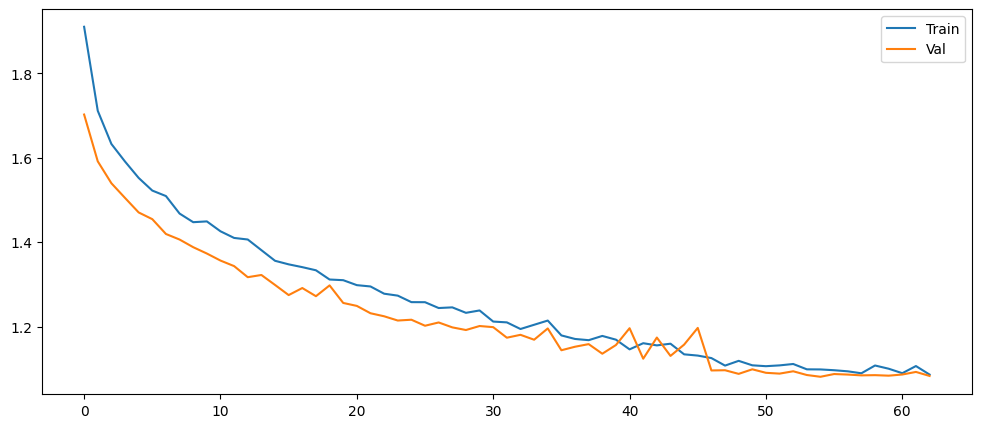

In [14]:
plt.figure(figsize=(12,5))
plt.plot(history["train_loss"], label="Train")
plt.plot(history["val_loss"], label="Val")
plt.legend()
plt.savefig(f"{OUTPUT_DIR}/loss_curve.png")
plt.show()

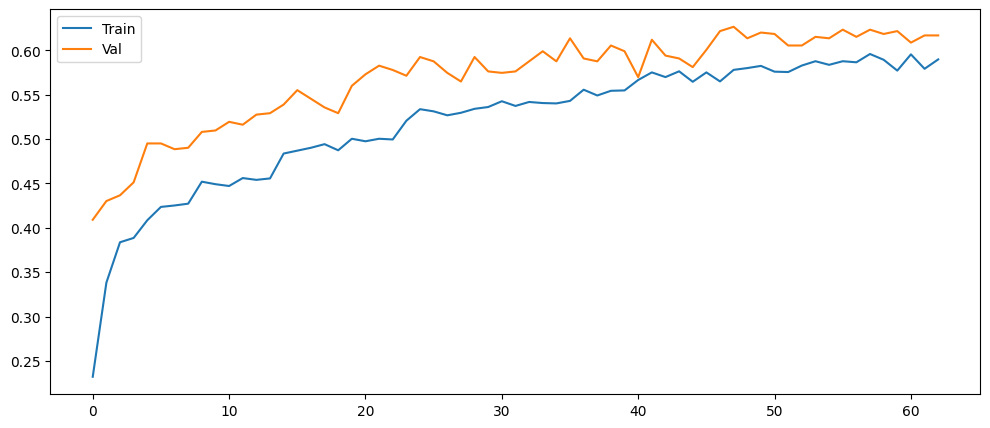

In [15]:
plt.figure(figsize=(12,5))
plt.plot(history["train_acc"], label="Train")
plt.plot(history["val_acc"], label="Val")
plt.legend()
plt.savefig(f"{OUTPUT_DIR}/acc_curve.png")
plt.show()

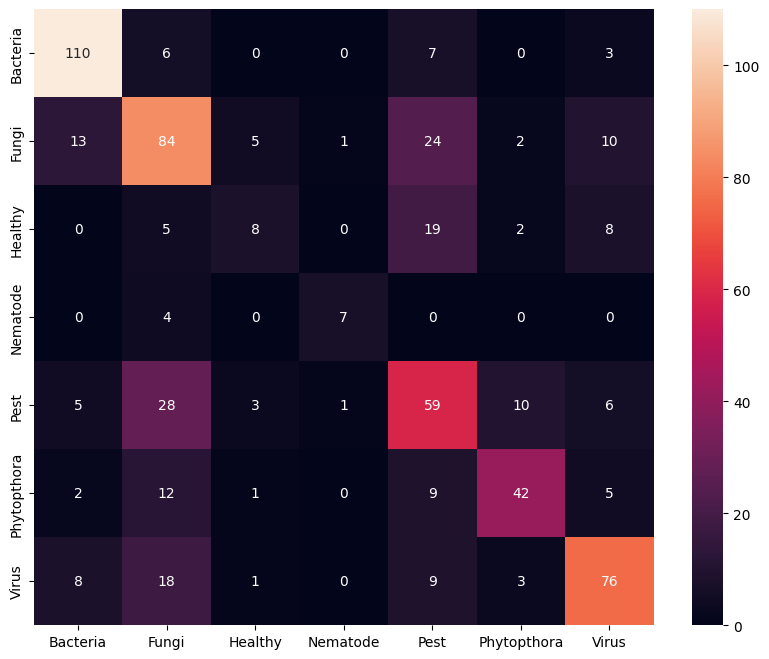

In [16]:
plt.figure(figsize=(10,8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.savefig(f"{OUTPUT_DIR}/confusion_matrix.png")
plt.show()